In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, cross_val_predict
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
def als_baseline(y, D, L, p = 0.01, niter = 10):
    """
    Asymmetric Least Squares baseline correction.
    
    Parameters:
        y    : spectrum intensity array
        lam  : smoothness (1e3 – 1e7); higher = smoother baseline
        p    : asymmetry (0.001 – 0.1); lower = baseline hugs the bottom
        niter: number of iterations
    """
    w = np.ones(L)

    for _ in range(niter):
        W = sparse.diags(w)
        Z = W + D
        z = spsolve(Z, w*y)
        w = p * (y > z) + (1 - p) * (y <= z)
    return z

In [3]:
df = pd.read_csv("02_feature_matrix_raw_T.csv", header = 0)

dataFrame = df.drop(columns=["Sample_ID", "Replica", "Origin", "Type"])

labels = (["Cotton"]*14 + ["Acrylic"]*18 + ["Nylon"]*18 + ["PP/PE"]*8 + ["Polyester"]*17 + ["Silk"]*11 + ["Wool"]*23)

ranges = [(24, 38), (50, 68), (70, 88), (88, 96), (96, 113), (125, 136), (137, 160)]
indices = np.concatenate([np.arange(s, e) for s, e in ranges])
spectrums_labeled = dataFrame.iloc[indices].reset_index(drop=True).copy()
spectrums_labeled.insert(loc = 2, column = "Labels", value = labels)
spectrums_labeled.iloc[:, :5].head(20)


,Spectrum_ID,Subtype,Labels,4000.0,3999.0
0,25,Cotton,Cotton,99.10,99.11
1,26,Cotton,Cotton,99.26,99.28
2,27,Cotton,Cotton,99.89,99.89
3,28,Cotton,Cotton,99.59,99.60
4,29,Cotton,Cotton,100.71,100.72
5,30,Cotton,Cotton,99.95,99.96
6,31,Cotton,Cotton,101.33,101.33
7,32,Cotton,Cotton,100.02,100.02
8,33,Cotton,Cotton,100.45,100.47
9,34,Cotton,Cotton,100.07,100.07


In [4]:
spectrums = spectrums_labeled.drop(columns=["Subtype"])

L = spectrums.iloc[:, 2:].shape[1]
D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(L - 2, L))
D = 1e5 * D.T @ D 

corrected = spectrums.copy()

for i in range(spectrums.shape[0]):
    y = spectrums.iloc[i, 2:].values.astype(float)
    baseline = als_baseline(y, D, L)
    corrected.iloc[i, 2:] = y - baseline

meta = corrected.iloc[:, :2].reset_index(drop=True)
values = corrected.iloc[:, 2:].astype(float)
    
normalized = values.copy()

for i in range(values.shape[0]):
    row = values.iloc[i].values
    normalized.iloc[i, :] = (row - row.mean())/row.std()

smoothed = normalized.copy()

for i in range(normalized.shape[0]):
    smoothed.iloc[i, :] = savgol_filter(normalized.iloc[i, :], window_length=9, polyorder=3)

final_df = pd.concat([meta, smoothed], axis=1)

final_df.iloc[:20, :6].head(20)

,Spectrum_ID,Labels,4000.0,3999.0,3998.0,3997.0
0,25,Cotton,-0.622644,-0.612657,-0.610001,-0.613199
1,26,Cotton,-0.615384,-0.601185,-0.590786,-0.584005
2,27,Cotton,-0.581537,-0.581484,-0.581587,-0.581481
3,28,Cotton,-0.639473,-0.626938,-0.620960,-0.619838
4,29,Cotton,-0.629731,-0.620984,-0.612284,-0.604668
5,30,Cotton,-0.632839,-0.624660,-0.625329,-0.632624
6,31,Cotton,-0.659039,-0.656144,-0.651993,-0.647204
7,32,Cotton,-0.565450,-0.563970,-0.562109,-0.560645
8,33,Cotton,-0.622046,-0.595300,-0.582625,-0.580772
9,34,Cotton,-0.576293,-0.576736,-0.580609,-0.586606


In [5]:
pca_full = PCA()
pca_full.fit(final_df.iloc[:, 2:].values)

# Calculate cumulative variance explained
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for 95%, 99% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_99 = np.argmax(cumulative_variance >= 0.99) + 1
print(n_components_95)
print(n_components_99)

12
27


(109, 12)


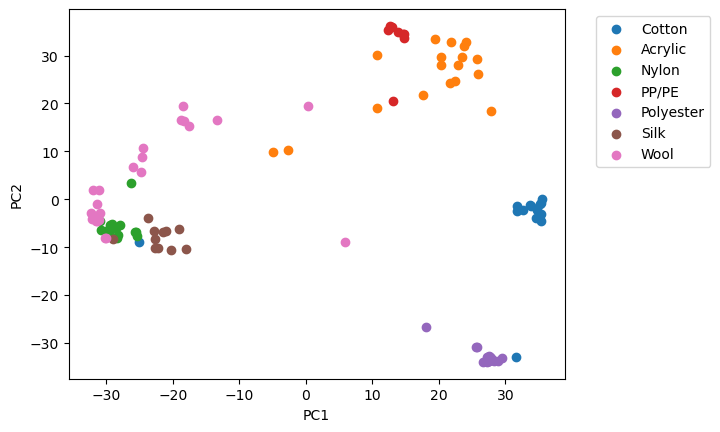

In [6]:
labels = final_df["Labels"]
codes, uniques = pd.factorize(labels)

pca = PCA(n_components=12)
pca_data = pca.fit_transform(final_df.iloc[:, 2:].values)
print(pca_data.shape)

for lab in uniques:
    idx = labels == lab
    plt.scatter(pca_data[idx, 0], pca_data[idx, 1], label=lab)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [7]:
param_grid = {"C": [0.1, 0.5, 1, 2, 5, 10], "gamma": [0.0005, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, "scale"], "kernel": ["rbf"]}

svm = SVC()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=57)

grid = GridSearchCV(estimator=svm, param_grid=param_grid, cv=skf, scoring="accuracy")
grid.fit(pca_data, labels)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

Best parameters: {'C': 0.5, 'gamma': 0.0005, 'kernel': 'rbf'}
Best CV accuracy: 0.9636363636363636


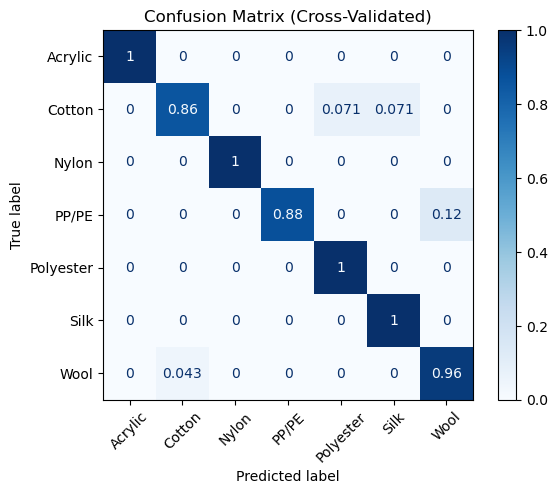


Classification Report:

              precision    recall  f1-score   support

     Acrylic       1.00      1.00      1.00        18
      Cotton       0.92      0.86      0.89        14
       Nylon       1.00      1.00      1.00        18
       PP/PE       1.00      0.88      0.93         8
   Polyester       0.94      1.00      0.97        17
        Silk       0.92      1.00      0.96        11
        Wool       0.96      0.96      0.96        23

    accuracy                           0.96       109
   macro avg       0.96      0.96      0.96       109
weighted avg       0.96      0.96      0.96       109

Fold accuracies: [0.95454545 0.95454545 0.90909091 1.         1.        ]
Mean accuracy: 0.9636363636363636
Std deviation: 0.034015067152490384


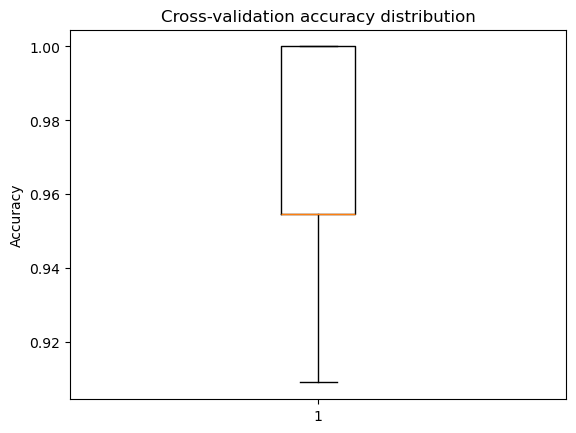

In [8]:
svm = SVC(kernel = "rbf", C=0.5, gamma=0.0005)

scores = cross_val_score(svm, pca_data, labels, cv=skf, scoring="accuracy")

# cross-validated predictions
y_pred = cross_val_predict(svm, pca_data, labels, cv=skf)

# confusion matrix
cm = confusion_matrix(labels, y_pred, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(labels))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix (Cross-Validated)")
plt.show()

# classification report
print("\nClassification Report:\n")
print(classification_report(labels, y_pred))

print("Fold accuracies:", scores)
print("Mean accuracy:", np.mean(scores))
print("Std deviation:", np.std(scores)) 

plt.boxplot(scores)
plt.title("Cross-validation accuracy distribution")
plt.ylabel("Accuracy")
plt.show()